# Leadership Council (LC) Analysis

**Definition:** A contact is LC if they have donated **$250 or more in the past 365 days**.

This notebook answers two questions:
1. Who is currently LC? (as of the last date in the dataset)
2. How many LC members did we have at each year-end snapshot (2010–2025)?

LC status is derived directly from contribution history — not from activist codes or source codes.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# Load contributions
contrib = pd.read_csv(
    '../../All Contributions Ever 4.9.26.xls',
    encoding='utf-16', sep='\t', on_bad_lines='skip', low_memory=False
)

# Load contacts (for name/location in export)
contacts = pd.read_csv(
    '../../Database List 4.9.26.xls',
    encoding='utf-16', sep='\t', on_bad_lines='skip', low_memory=False
)

print(f'Contributions loaded: {len(contrib):,} rows')
print(f'Contacts loaded:      {len(contacts):,} rows')

Contributions loaded: 53,024 rows
Contacts loaded:      80,892 rows


## Step 1: Clean contributions


In [2]:
contrib['date'] = pd.to_datetime(contrib['Date Received'], errors='coerce')
contrib = contrib[contrib['date'].notna()].copy()
contrib['amount'] = pd.to_numeric(contrib['Amount'], errors='coerce').fillna(0)
contrib = contrib[contrib['amount'] > 0].copy()
contrib = contrib.rename(columns={'VANID': 'vanid'})
contrib = contrib[['vanid', 'date', 'amount']].sort_values(['vanid', 'date']).reset_index(drop=True)

DATA_THROUGH = contrib['date'].max()
print(f'Clean contributions: {len(contrib):,} rows')
print(f'Date range:          {contrib["date"].min().date()} -> {DATA_THROUGH.date()}')
print(f'Unique donors:       {contrib["vanid"].nunique():,}')

Clean contributions: 53,022 rows
Date range:          2004-01-15 -> 2026-04-09
Unique donors:       7,770


## Step 2: Current LC members (past 365 days as of last data date)

Who has given $250 or more in the 365 days ending on the last date in the dataset?

In [3]:
window_start = DATA_THROUGH - pd.Timedelta(days=364)
current_window = contrib[
    (contrib['date'] >= window_start) & (contrib['date'] <= DATA_THROUGH)
].groupby('vanid')['amount'].sum().reset_index()
current_window.columns = ['vanid', 'total_365']

current_lc = current_window[current_window['total_365'] >= 250].copy()

# Build contact_name lookup from contributions (covers orgs with no First/Last)
contact_names = (
    pd.read_csv(
        '../../All Contributions Ever 4.9.26.xls',
        encoding='utf-16', sep='\t', on_bad_lines='skip', low_memory=False
    )[["VANID", "Contact Name"]]
    .drop_duplicates(subset="VANID")
    .rename(columns={"VANID": "vanid", "Contact Name": "contact_name"})
)
contact_names["vanid"] = contact_names["vanid"].astype(str)

# Join contact info
contacts_slim = contacts[['VANID', 'First', 'Last', 'PreferredEmail', 'City', 'State/Province']].copy()
contacts_slim.columns = ['vanid', 'first', 'last', 'email', 'city', 'state']
contacts_slim["vanid"] = contacts_slim["vanid"].astype(str)
current_lc["vanid"] = current_lc["vanid"].astype(str)

current_lc = current_lc.merge(contacts_slim, on='vanid', how='left')
current_lc = current_lc.merge(contact_names, on="vanid", how="left")
current_lc = current_lc.sort_values('total_365', ascending=False).reset_index(drop=True)

print(f'As of {DATA_THROUGH.date()} — current LC members: {len(current_lc):,}')
print(f'Window: {window_start.date()} -> {DATA_THROUGH.date()}')
current_lc.head(10)

As of 2026-04-09 — current LC members: 324
Window: 2025-04-10 -> 2026-04-09


,vanid,total_365,first,last,email,city,state,contact_name
0,113846390,104803.42,NaN,NaN,NaN,Phoenix,AZ,Instituto Lab
1,109416139,83000.00,NaN,NaN,pam@plgfree.com,Tucson,AZ,Pam Grissom
2,109420495,20000.00,NaN,NaN,NaN,Washington,DC,American Bridge 21st Century
3,131853787,20000.00,NaN,NaN,NaN,San Francisco,CA,Murphy-Neilan Trust
4,109434574,20000.00,NaN,NaN,NaN,Washington,DC,Giffords PAC
5,109442205,20000.00,NaN,NaN,terik@ufcw99.com,Phoenix,AZ,UFCW Local 99
6,131049110,17800.00,NaN,NaN,elvira@adelitaforcongress.com,Tucson,AZ,La Gente for Grijalva
7,109460971,15000.00,NaN,NaN,NaN,Lakeside,AZ,Navajo County Democratic Committee
8,109429695,15000.00,Bill,Roe,bill@roemail.net,Tucson,AZ,"Roe, Bill G"
9,129149302,11742.08,NaN,NaN,NaN,Washington,DC,"GMMB, Inc."


## Step 3: Export current LC member list


In [4]:
export_path = f'current_lc_members_{DATA_THROUGH.strftime("%Y%m%d")}.csv'
current_lc.to_csv(export_path, index=False)
print(f'Exported: {export_path} ({len(current_lc):,} members)')

Exported: current_lc_members_20260409.csv (324 members)


## Step 4: Annual LC snapshots (rolling 365-day)

For each year 2010-2025, snapshot is Dec 31.  
For 2026, snapshot is the last date in the dataset to avoid undercounting.

In [5]:
records = []

for year in range(2004, 2026):
    snapshot_date = pd.Timestamp(f'{year}-12-31')
    window_start  = snapshot_date - pd.Timedelta(days=364)
    window = contrib[
        (contrib['date'] >= window_start) & (contrib['date'] <= snapshot_date)
    ].groupby('vanid')['amount'].sum()
    records.append({'year': str(year), 'snapshot': str(snapshot_date.date()), 'lc_members': int((window >= 250).sum())})

# 2026: use actual last data date instead of Dec 31
window_start = DATA_THROUGH - pd.Timedelta(days=364)
window = contrib[
    (contrib['date'] >= window_start) & (contrib['date'] <= DATA_THROUGH)
].groupby('vanid')['amount'].sum()
records.append({'year': '2026*', 'snapshot': str(DATA_THROUGH.date()), 'lc_members': int((window >= 250).sum())})

snapshots = pd.DataFrame(records)
print(snapshots.to_string(index=False))
print('\n* 2026 snapshot is as of last data date, not Dec 31')


 year   snapshot  lc_members
 2004 2004-12-31          33
 2005 2005-12-31          40
 2006 2006-12-31          53
 2007 2007-12-31          62
 2008 2008-12-31          56
 2009 2009-12-31          86
 2010 2010-12-31         148
 2011 2011-12-31         210
 2012 2012-12-31         200
 2013 2013-12-31         157
 2014 2014-12-31         165
 2015 2015-12-31         172
 2016 2016-12-31         211
 2017 2017-12-31         224
 2018 2018-12-31         316
 2019 2019-12-31         250
 2020 2020-12-31         256
 2021 2021-12-31         264
 2022 2022-12-31         295
 2023 2023-12-31         291
 2024 2024-12-31         333
 2025 2025-12-31         324
2026* 2026-04-09         324

* 2026 snapshot is as of last data date, not Dec 31


## Step 5: LC membership trend (line chart)


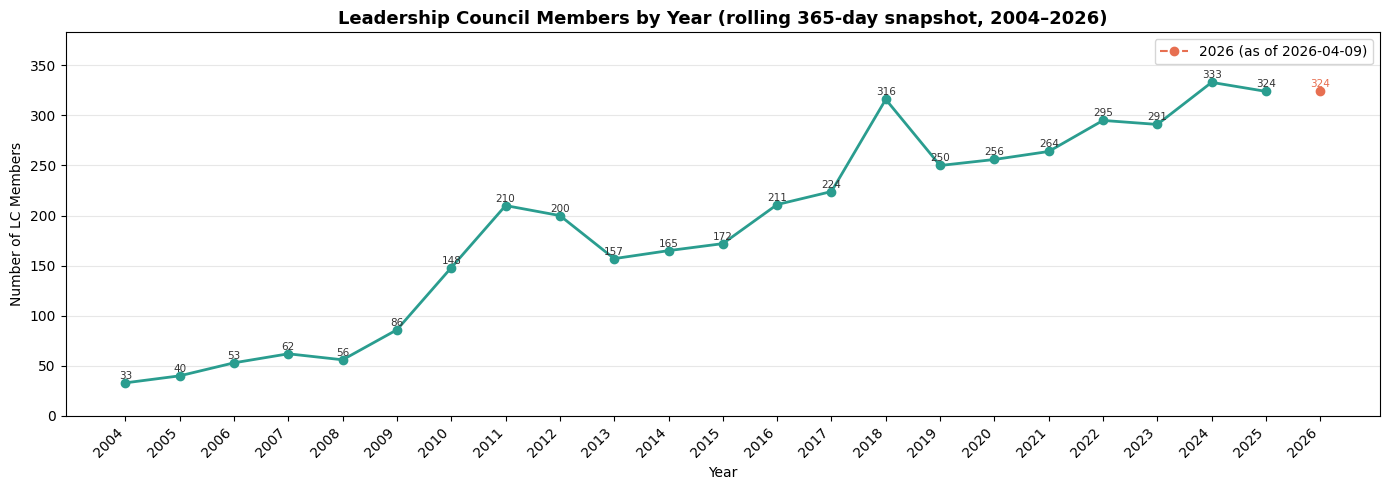

Saved: analysis/figures/lc_members_by_year.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

full_years = snapshots[snapshots['year'] != '2026*']
partial    = snapshots[snapshots['year'] == '2026*']

x_full = [int(y) for y in full_years['year']]
ax.plot(x_full, full_years['lc_members'], marker='o', linewidth=2, color='#2a9d8f', markersize=6)
ax.plot(2026, partial['lc_members'].values[0], marker='o', markersize=6,
        color='#e76f51', linestyle='--', linewidth=1.5, label=f'2026 (as of {DATA_THROUGH.date()})')

for _, row in full_years.iterrows():
    ax.text(int(row['year']), row['lc_members'] + 4, str(row['lc_members']),
            ha='center', fontsize=7.5, color='#333')
ax.text(2026, partial['lc_members'].values[0] + 4, str(partial['lc_members'].values[0]),
        ha='center', fontsize=7.5, color='#e76f51')

ax.set_title('Leadership Council Members by Year (rolling 365-day snapshot, 2004–2026)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of LC Members')
ax.set_xticks(list(range(2004, 2027)))
ax.set_xticklabels([str(y) for y in range(2004, 2027)], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, snapshots['lc_members'].max() * 1.15)
ax.legend()

plt.tight_layout()
plt.savefig('../figures/lc_members_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: analysis/figures/lc_members_by_year.png')
